在 tf_keras_classification.ipynb 中，我们直接将像素点输进去了，没有标准化。这次尝试标准化，看看准确率有没有提升。

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
import tensorflow as tf

from tensorflow import keras

print(tf.__version__)
print(sys.version_info)
for module in mpl, np, pd, sklearn, tf, keras:
    print(module.__name__, module.__version__)


2025-05-21 16:20:56.136015: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-21 16:20:56.136763: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-21 16:20:56.139319: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-21 16:20:56.146381: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747815656.158293   25235 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747815656.16

2.19.0
sys.version_info(major=3, minor=11, micro=2, releaselevel='final', serial=0)
matplotlib 3.10.3
numpy 2.1.3
pandas 2.2.3
sklearn 1.6.1
tensorflow 2.19.0
keras._tf_keras.keras 3.9.2


In [2]:
fashion_mnist = keras.datasets.fashion_mnist
(x_train_all, y_train_all), (x_test, y_test) = fashion_mnist.load_data()
x_valid, x_train = x_train_all[:5000], x_train_all[5000:]
y_valid, y_train = y_train_all[:5000], y_train_all[5000:]

print(x_valid.shape, y_valid.shape)
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(5000, 28, 28) (5000,)
(55000, 28, 28) (55000,)
(10000, 28, 28) (10000,)


In [3]:
print(np.max(x_train), np.min(x_train))

255 0


In [4]:
x_train.reshape(-1, 1).shape

(43120000, 1)

In [5]:
# x = (x - u) / std
# 通过原有sk的标准化进行处理
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# x_train: [None, 28, 28] -> [None, 784]

#先reshape变为二维（相当于1列）的目的是对每一个像素点进行标准化（让其等价）
x_train_scaled = scaler.fit_transform(x_train.astype(np.float32).reshape(-1, 1)) \
                        .reshape(-1, 28, 28)

#这个是验证集，验证集用的也是训练集的均值和方差
x_valid_scaled = scaler.transform(x_valid.astype(np.float32).reshape(-1, 1))  \
                        .reshape(-1, 28, 28)

#这个是测试集
x_test_scaled = scaler.transform(x_test.astype(np.float32).reshape(-1, 1))     \
                        .reshape(-1, 28, 28)

In [6]:
print(np.max(x_train_scaled), np.min(x_train_scaled))

2.0231433 -0.8105136


In [7]:
# tf.keras.models.Sequential()

"""
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28, 28]))
model.add(keras.layers.Dense(300, activation="relu"))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dense(10, activation="softmax"))
"""

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation='relu'),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# relu: y = max(0, x)
# softmax: 将向量变成概率分布. x = [x1, x2, x3], 
#          y = [e^x1/sum, e^x2/sum, e^x3/sum], sum = e^x1 + e^x2 + e^x3

# reason for sparse: y->index. y->one_hot->[] 
model.compile(loss="sparse_categorical_crossentropy",
              optimizer = keras.optimizers.SGD(0.001),
              metrics = ["accuracy"])

/home/zhiyue/Documents/myvenv/tf/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2025-05-21 16:20:58.126115: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [8]:
#如果再次直接fit是接着之前的进行训练的，如果要从头训练，要重新执行上面代码
history = model.fit(x_train_scaled, y_train, epochs=20,
                    validation_data=(x_valid_scaled, y_valid))

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.5972 - loss: 1.2419 - val_accuracy: 0.7978 - val_loss: 0.6045
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7910 - loss: 0.5966 - val_accuracy: 0.8254 - val_loss: 0.5147
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8153 - loss: 0.5198 - val_accuracy: 0.8362 - val_loss: 0.4754
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8279 - loss: 0.4807 - val_accuracy: 0.8474 - val_loss: 0.4493
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8392 - loss: 0.4517 - val_accuracy: 0.8528 - val_loss: 0.4329
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8456 - loss: 0.4362 - val_accuracy: 0.8532 - val_loss: 0.4253
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8497 - loss: 0.4237 - val_accuracy: 0.8618 - val_loss: 0.4073
Epoch 8/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8527 - loss: 0.4152

In [9]:
print(type(history.history))
print(history.history)

<class 'dict'>
{'accuracy': [0.7092000246047974, 0.8002545237541199, 0.8200545310974121, 0.8320181965827942, 0.840254545211792, 0.8466727137565613, 0.8513454794883728, 0.8558181524276733, 0.8594727516174316, 0.862672746181488, 0.8644000291824341, 0.8677818179130554, 0.8697090744972229, 0.8718727231025696, 0.8745272755622864, 0.8755090832710266, 0.8772545456886292, 0.8784545660018921, 0.879763662815094, 0.8814727067947388], 'loss': [0.8902055621147156, 0.5725951790809631, 0.5083674192428589, 0.4735039174556732, 0.44982826709747314, 0.43246474862098694, 0.41868850588798523, 0.40687987208366394, 0.39729565382003784, 0.38850176334381104, 0.3806650638580322, 0.3741713762283325, 0.36818060278892517, 0.36224615573883057, 0.3570845425128937, 0.3524339199066162, 0.3477567136287689, 0.3436165153980255, 0.3394075036048889, 0.33559364080429077], 'val_accuracy': [0.7978000044822693, 0.8253999948501587, 0.8361999988555908, 0.8474000096321106, 0.8528000116348267, 0.8532000184059143, 0.861800014972686

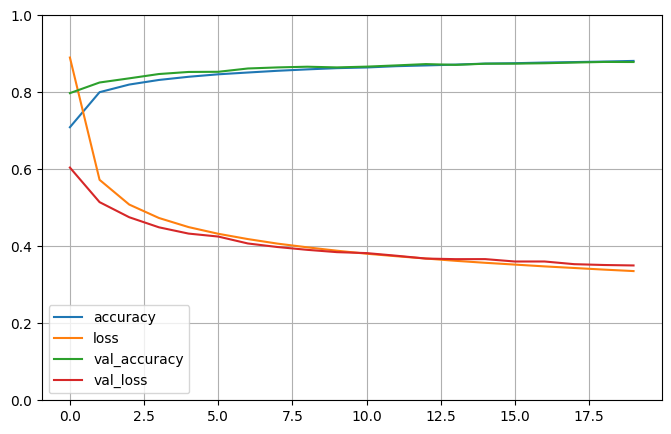

In [10]:
def plot_learning_curves(history):
    pd.DataFrame(history.history).plot(figsize=(8, 5))
    plt.grid(True)
    plt.gca().set_ylim(0, 1)
    plt.show()

plot_learning_curves(history)

In [11]:
model.evaluate(x_test_scaled, y_test, verbose=0)

[0.38868293166160583, 0.8597999811172485]